# Assignment 2: AI-Driven Energy Forecasting for Cost and Carbon-Aware Industrial Scheduling

**Team Members:** Furkan Kartal, Cansu Koçer, Feyza Aydınalp, Umut Emre Çakır

**Objective:** Build and evaluate machine learning models to predict `price actual` based on temporal features and energy generation, allowing us to identify "green windows" (low cost, high renewable generation) for dynamic workload scheduling.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings('ignore')
plt.style.use('ggplot')
sns.set_theme(style="whitegrid")

## 2. Data Loading & Preprocessing
Building upon our previous homework, we load the dataset, handle missing values using forward-fill interpolation (to preserve time-series continuity), and parse timestamps.

In [2]:
# Load the dataset
df = pd.read_csv("energy_dataset-2.csv")

# Drop columns that are completely empty
df = df.dropna(axis=1, how='all')

# Datetime conversion
if 'time' in df.columns:
    df['time'] = pd.to_datetime(df['time'], utc=True)

# Forward-fill missing values for time-series continuity
df = df.ffill()
df = df.bfill() # Catch any initial NaNs

print(f"Dataset Shape: {df.shape}")

Dataset Shape: (35064, 27)


## 3. Feature Engineering
Extracting explicit temporal features (Hour, Day) to help the model capture cyclical generation patterns. We also aggregate individual fuel columns into simplified `Total_Renewable` and `Total_Fossil` metrics.

In [3]:
# Temporal Features
df['Hour'] = df['time'].dt.hour
df['DayOfWeek'] = df['time'].dt.dayofweek
df['Month'] = df['time'].dt.month

# Aggregating Generation Types
renewable_cols = [
    'generation solar', 'generation wind onshore', 'generation wind offshore',
    'generation hydro run-of-river and poundage', 'generation hydro water reservoir',
    'generation biomass', 'generation geothermal'
]
fossil_cols = [
    'generation fossil brown coal/lignite', 'generation fossil gas',
    'generation fossil hard coal', 'generation fossil oil',
    'generation fossil coal-derived gas'
]

# Create aggregated columns
df['Total_Renewable'] = df[[c for c in renewable_cols if c in df.columns]].sum(axis=1)
df['Total_Fossil'] = df[[c for c in fossil_cols if c in df.columns]].sum(axis=1)

df[['time', 'Hour', 'Total_Renewable', 'Total_Fossil', 'price actual']].head()

,time,Hour,Total_Renewable,Total_Fossil,price actual
0,2014-12-31 23:00:00+00:00,23,9824.0,10156.0,65.41
1,2015-01-01 00:00:00+00:00,0,9056.0,10437.0,64.92
2,2015-01-01 01:00:00+00:00,1,8303.0,9918.0,64.48
3,2015-01-01 02:00:00+00:00,2,7454.0,8859.0,59.32
4,2015-01-01 03:00:00+00:00,3,7078.0,8313.0,56.04


## 4. Exploratory Data Analysis (EDA)
As outlined in our project deliverables, we visualize the inverse correlation between renewable generation and energy prices to validate our hypothesis about "green windows".

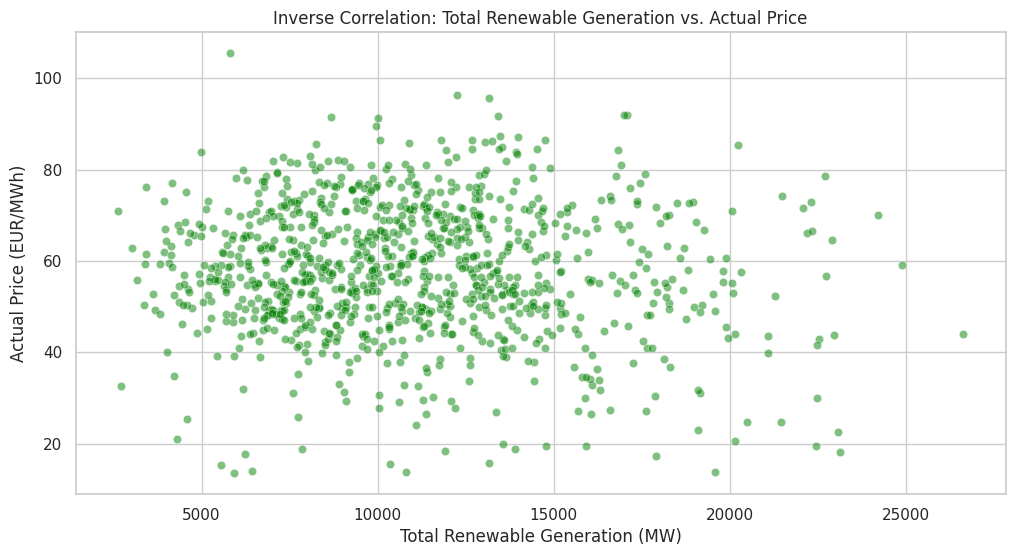

In [4]:
plt.figure(figsize=(12, 6))
subset = df.sample(1000, random_state=42) # Sample for clearer plotting
sns.scatterplot(x='Total_Renewable', y='price actual', data=subset, alpha=0.5, color='green')
plt.title('Inverse Correlation: Total Renewable Generation vs. Actual Price')
plt.xlabel('Total Renewable Generation (MW)')
plt.ylabel('Actual Price (EUR/MWh)')
plt.show()

## 5. Data Preparation for Modeling
We select our features and target, split the data into 80% training and 20% test sets, and standardize the numerical values.

In [5]:
features = ['Hour', 'DayOfWeek', 'Month', 'Total_Renewable', 'Total_Fossil', 'total load actual']
target = 'price actual'

X = df[features]
y = df[target]

# Train-Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 6. Model Training & Evaluation: Random Forest Regressor
Random Forest is effective at capturing the non-linear relationships between cyclical time factors and generation mixes.

--- Random Forest Metrics ---
RMSE: 7.31
MAE:  5.48
R2:   0.74


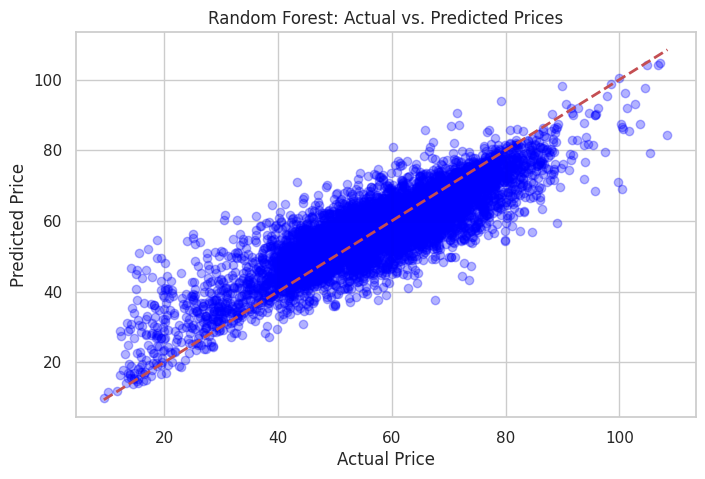

In [6]:
# Initialize and train the model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)

# Predict and Evaluate
rf_preds = rf_model.predict(X_test_scaled)

print("--- Random Forest Metrics ---")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, rf_preds)):.2f}")
print(f"MAE:  {mean_absolute_error(y_test, rf_preds):.2f}")
print(f"R2:   {r2_score(y_test, rf_preds):.2f}")

# Error Plot: Actual vs Predicted
plt.figure(figsize=(8, 5))
plt.scatter(y_test, rf_preds, alpha=0.3, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Random Forest: Actual vs. Predicted Prices')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.show()

## 7. Model Training & Evaluation: Gradient Boosting Regressor
Testing an ensemble boosting method to see if sequential tree building reduces our error margin further.

In [7]:
# Initialize and train Gradient Boosting
gb_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb_model.fit(X_train_scaled, y_train)

# Predict and Evaluate
gb_preds = gb_model.predict(X_test_scaled)

print("--- Gradient Boosting Metrics ---")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, gb_preds)):.2f}")
print(f"MAE:  {mean_absolute_error(y_test, gb_preds):.2f}")
print(f"R2:   {r2_score(y_test, gb_preds):.2f}")

--- Gradient Boosting Metrics ---
RMSE: 9.61
MAE:  7.53
R2:   0.54


## 8. Feature Importance Interpretation
Understanding which variables drive the price prediction helps us validate our scheduling logic.

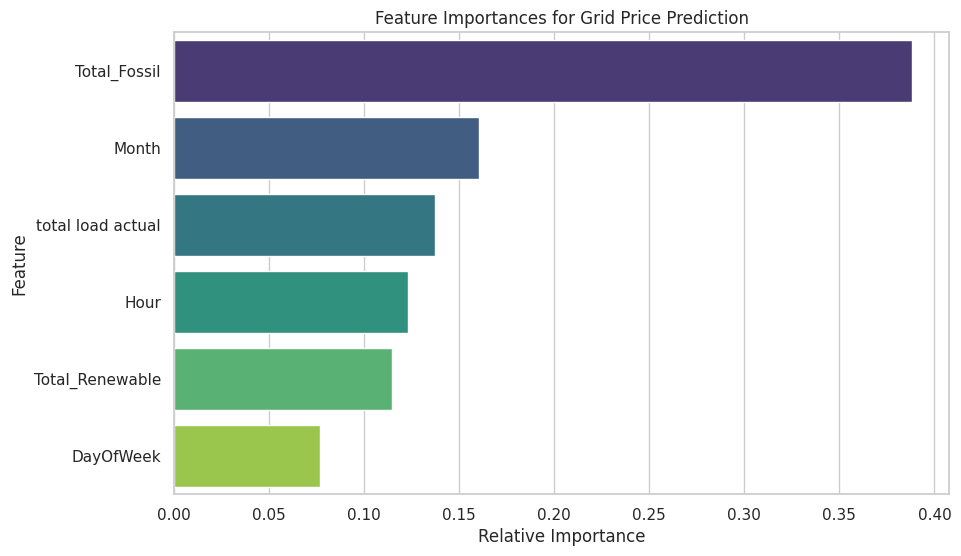

In [8]:
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
sns.barplot(x=importances[indices], y=np.array(features)[indices], palette="viridis")
plt.title('Feature Importances for Grid Price Prediction')
plt.xlabel('Relative Importance')
plt.ylabel('Feature')
plt.show()